<a href="https://colab.research.google.com/github/Faizaa01/Machine_Learning_Fundamentals/blob/main/NutriScore_Predictor_ML_Based_Food_Health_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import uniform, randint

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# 2. Load Dataset

import kagglehub
import os

path = kagglehub.dataset_download("ahsanneural/global-food-and-nutrition-database-2026")
print("Path to dataset files:", path)
os.listdir(path)

df = pd.read_csv(os.path.join(path, "comprehensive_foods_usda.csv"))
print("Dataset shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'global-food-and-nutrition-database-2026' dataset.
Path to dataset files: /kaggle/input/global-food-and-nutrition-database-2026
Dataset shape: (40000, 24)


,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_size,serving_unit,household_serving,...,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
0,167782,"Abiyuch, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,1.50,0.014,54.1,5.3,1.61,20.0,8.55,NaN,65,Fruits
1,171687,"Acerola juice, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1600.0,0.3,0.50,3.0,4.50,0.0,55,Fruits
2,171686,"Acerola, (west indian cherry), raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1680.0,1.1,0.20,7.0,NaN,0.0,55,Fruits
3,168061,Acorn stew (Apache),SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,6.81,1.280,0.0,0.7,1.00,130.0,0.34,20.0,50,Other
4,168992,"Agave, cooked (Southwest)",SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,0.99,NaN,0.3,10.6,3.55,13.0,20.90,0.0,50,Other


In [ ]:
# 3. Data Exploration - Summary Statistics

df.describe()

,fdc_id,serving_size,calories,carbs_g,calcium_mg,fat_g,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score
count,4.000000e+04,31842.000000,39538.000000,39411.000000,34215.000000,39713.000000,39747.000000,35014.000000,22940.000000,33725.000000,34250.000000,3.938300e+04,35739.000000,34158.000000,40000.000000
mean,1.793461e+06,92.563962,308.159861,28.420500,106.091172,12.118343,8.260691,4.451546,24.138259,2.568491,2.389289,1.067233e+03,13.262690,62.575833,48.887250
std,8.964022e+05,100.581765,392.575965,47.614576,1327.632746,19.140351,10.668951,7.387522,1419.157682,5.662308,60.647733,2.895701e+04,36.323827,2141.337343,9.850912
min,1.675120e+05,0.000000,0.000000,-0.705000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,20.000000
25%,1.459896e+06,28.000000,85.000000,3.570000,5.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.030000,1.600000e+01,0.000000,0.000000,40.000000
50%,2.094756e+06,55.000000,250.000000,15.600000,29.000000,4.550000,5.130000,1.670000,0.000000,1.000000,0.980000,1.430000e+02,4.520000,0.000000,50.000000
75%,2.469605e+06,118.000000,404.000000,51.800000,98.000000,17.600000,12.500000,6.077500,5.200000,3.300000,2.280000,4.810000e+02,16.700000,38.000000,55.000000
max,2.752382e+06,5055.000000,37600.000000,6160.000000,150000.000000,1170.000000,760.000000,300.000000,210000.000000,588.000000,8930.000000,4.690000e+06,5560.000000,214000.000000,75.000000


In [ ]:
# 4. Data Exploration - Data Types and Null Counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fdc_id             40000 non-null  int64  
 1   food_name          40000 non-null  object 
 2   data_type          40000 non-null  object 
 3   food_category      39954 non-null  object 
 4   brand_owner        31383 non-null  object 
 5   brand_name         30254 non-null  object 
 6   ingredients        31656 non-null  object 
 7   serving_size       31842 non-null  float64
 8   serving_unit       31842 non-null  object 
 9   household_serving  30790 non-null  object 
 10  calories           39538 non-null  float64
 11  carbs_g            39411 non-null  float64
 12  calcium_mg         34215 non-null  float64
 13  fat_g              39713 non-null  float64
 14  protein_g          39747 non-null  float64
 15  saturated_fat_g    35014 non-null  float64
 16  vitamin_c_mg       229

In [ ]:
# 5. Data Exploration - Unique Values

df.nunique()

,0
fdc_id,40000
food_name,30900
data_type,3
food_category,240
brand_owner,5559
brand_name,7174
ingredients,24696
serving_size,635
serving_unit,8
household_serving,4226


In [ ]:
# 6. Drop Irrelevant Columns

cols_to_drop = ['fdc_id', 'food_name', 'brand_owner', 'brand_name',
                'ingredients', 'serving_size', 'serving_unit', 'household_serving']

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [ ]:
# 7. Handle Missing Values

numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df['food_category'] = df['food_category'].fillna(df['food_category'].mode()[0])

print(df.isnull().sum())

data_type          0
food_category      0
calories           0
carbs_g            0
calcium_mg         0
fat_g              0
protein_g          0
saturated_fat_g    0
vitamin_c_mg       0
fiber_g            0
iron_mg            0
sodium_mg          0
sugar_g            0
cholesterol_mg     0
health_score       0
food_type          0
dtype: int64


In [ ]:
# 8. Feature Correlation with Health Score

corr = df.select_dtypes(include='number').corr()['health_score'].drop('health_score').sort_values()
print(corr)

saturated_fat_g   -0.372986
fat_g             -0.240585
sugar_g           -0.235938
calories          -0.124918
carbs_g           -0.102587
sodium_mg         -0.021410
calcium_mg        -0.014079
cholesterol_mg    -0.005424
vitamin_c_mg       0.005870
iron_mg            0.012226
fiber_g            0.252088
protein_g          0.288869
Name: health_score, dtype: float64


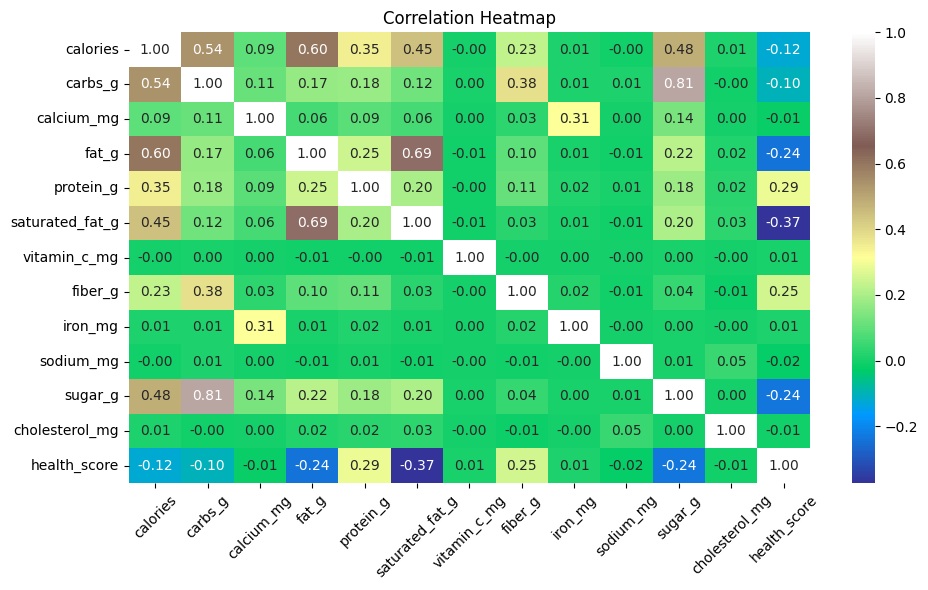

In [ ]:
# 9. Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='terrain')
plt.xticks(rotation=45)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

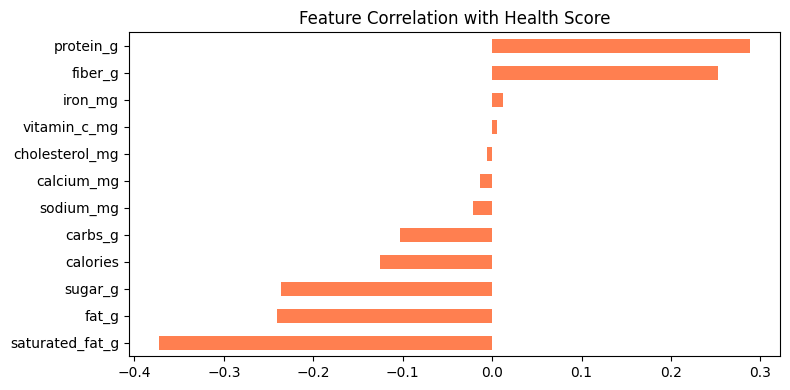

In [ ]:
# 10. Top Feature Correlations with Health Score

corr = df.select_dtypes(include='number').corr()['health_score'].drop('health_score').sort_values()
plt.figure(figsize=(8,4))
corr.plot(kind='barh', color='coral')
plt.title('Feature Correlation with Health Score')
plt.tight_layout()
plt.show()

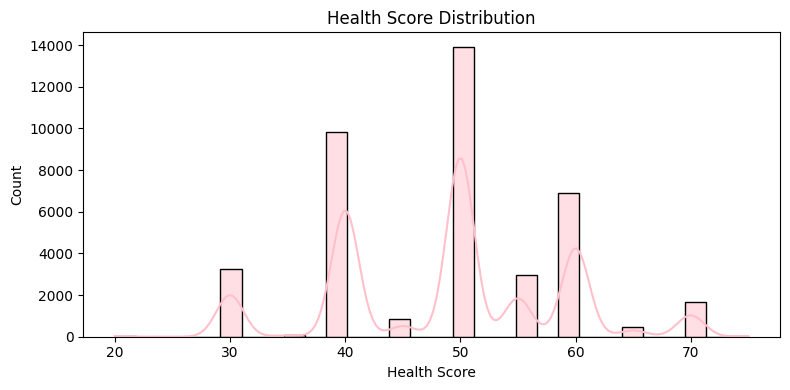

In [ ]:
# 11. Health Score Distribution

plt.figure(figsize=(8,4))
sns.histplot(df['health_score'], bins=30, kde=True, color='pink')
plt.title('Health Score Distribution')
plt.xlabel('Health Score')
plt.tight_layout()
plt.show()

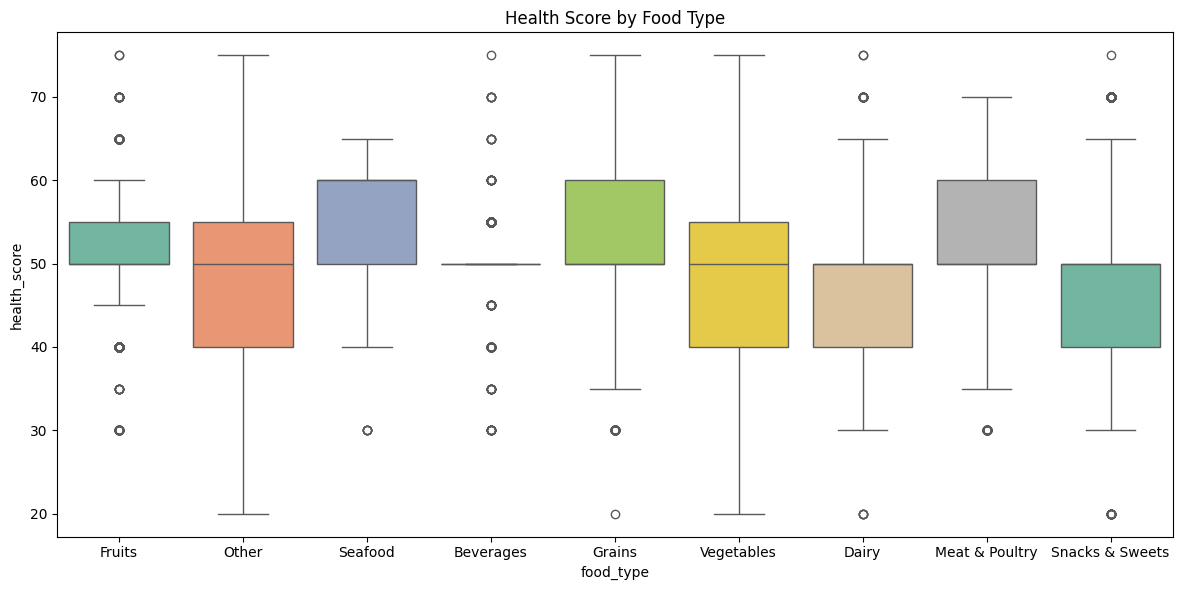

In [ ]:
# 12. Health Score Distribution by Food Type

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='food_type', y='health_score', palette='Set2')
plt.title('Health Score by Food Type')
plt.tight_layout()
plt.show()

In [ ]:
# 13. Define Features, Target and Preprocessing Pipeline

X = df.drop(columns=['health_score'])
y = df['health_score']


numeric_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = ['food_type', 'food_category', 'data_type']


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, cat_cols)
])

In [ ]:
# 14. Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(32000, 15) (8000, 15)


In [ ]:
# 15. Train and Compare All Models

models = {
    'Linear Regression' : Pipeline(steps=[('preprocessor', preprocessor), ('model', LinearRegression())]),
    'Decision Tree'     : Pipeline(steps=[('preprocessor', preprocessor), ('model', DecisionTreeRegressor(random_state=42))]),
    'Random Forest'     : Pipeline(steps=[('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42))]),
    'Gradient Boosting' : Pipeline(steps=[('preprocessor', preprocessor), ('model', GradientBoostingRegressor(random_state=42))]),
    'XGBoost'           : Pipeline(steps=[('preprocessor', preprocessor), ('model', XGBRegressor(random_state=42))])
}

results = []

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results.append({
      'Model': name,
      'R2 Score': r2,
      'RMSE': rmse,
      'MAE': mae
  })

result_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False)
result_df

,Model,R2 Score,RMSE,MAE
3,Gradient Boosting,0.999800,0.139815,0.085035
1,Decision Tree,0.999425,0.237171,0.006250
2,Random Forest,0.999393,0.243695,0.011031
4,XGBoost,0.996241,0.606465,0.112128
0,Linear Regression,0.119954,9.279156,4.540767


In [ ]:
# 16. Hyperparameter Tuning - Gradient Boosting (RandomizedSearchCV)

param_dist = {
    'model__n_estimators': randint(100, 300),
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': uniform(0.01, 0.1),
    'model__subsample': [0.8, 1.0]
}

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

random_search = RandomizedSearchCV(gb_pipeline, param_dist, n_iter=10, cv=3,
                                   scoring='r2', n_jobs=-1, random_state=42, verbose=1)
random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best R2:", random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params: {'model__learning_rate': np.float64(0.08796910002727693), 'model__max_depth': 3, 'model__n_estimators': 202, 'model__subsample': 1.0}
Best R2: 0.9998197183451664


In [ ]:
# 17. Final Model Evaluation - Tuned Gradient Boosting

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.9998913818411829
RMSE: 0.10308773534566283
MAE: 0.039494589668684875


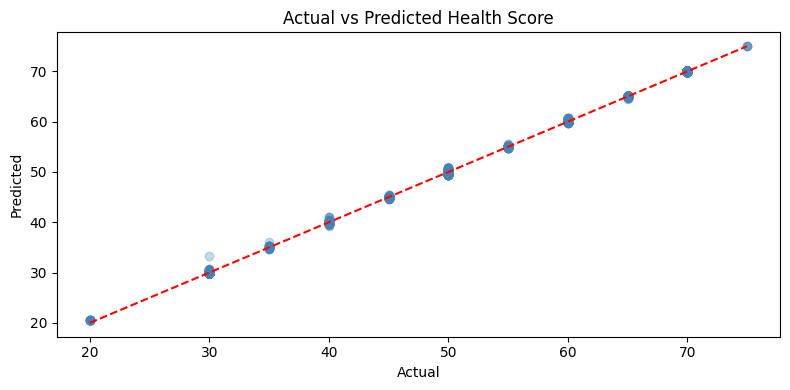

In [ ]:
# 18. Actual vs Predicted Plot

plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Health Score')
plt.tight_layout()
plt.show()

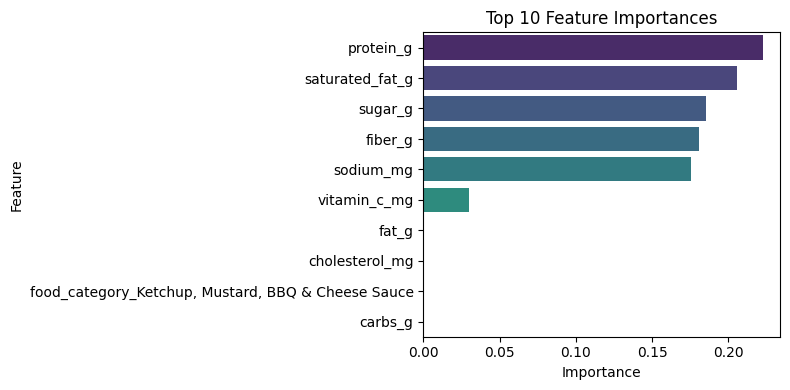

In [ ]:
# 19. Feature Importance Plot

feature_names = (numeric_cols + list(best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)))

importances = best_model.named_steps['model'].feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8,4))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

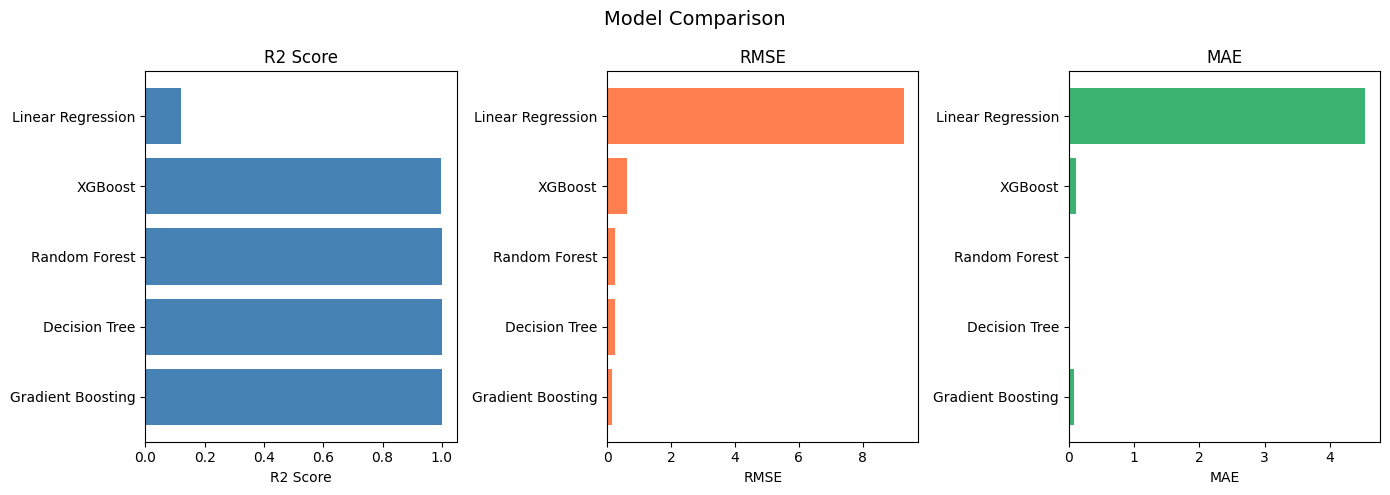

In [ ]:
# 20. Model Comparison Plot

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['R2 Score', 'RMSE', 'MAE']
colors = ['steelblue', 'coral', 'mediumseagreen']

for i, metric in enumerate(metrics):
    axes[i].barh(result_df['Model'], result_df[metric], color=colors[i])
    axes[i].set_title(metric)
    axes[i].set_xlabel(metric)

plt.suptitle('Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()